In [ ]:
from numba import cuda

In [ ]:
# WAP to cuda matrix multipication

In [ ]:
import numpy as np
from numba import cuda

@cuda.jit
def matmul(A, B, C):
    i, j = cuda.grid(2)
    if i < C.shape[0] and j < C.shape[1]:
        s = 0
        for k in range(A.shape[1]):
            s += A[i, k] * B[k, j]
        C[i, j] = s

In [ ]:
# Big matrix size
N = 512

A = np.random.rand(N, N).astype(np.float32)
B = np.random.rand(N, N).astype(np.float32)
C = np.zeros((N, N), dtype=np.float32)


In [ ]:
# Copy to GPU
d_A = cuda.to_device(A)
d_B = cuda.to_device(B)
d_C = cuda.to_device(C)


In [ ]:
# Kernel launch
threadsperblock = (16, 16)
blockspergrid = ((N + 15) // 16, (N + 15) // 16)
matmul[blockspergrid, threadsperblock](d_A, d_B, d_C)

In [ ]:
# Copy result back
C = d_C.copy_to_host()

In [ ]:
# Print results
print("Matrix A:")
print(A)

print("\nMatrix B:")
print(B)

print("\nResult Matrix C (A × B):")
print(C)

Matrix A:
[[0.27693525 0.94390523 0.80878437 ... 0.13714916 0.6164373  0.19601344]
 [0.8916494  0.88958335 0.3889994  ... 0.40605414 0.23044221 0.85853076]
 [0.14614445 0.10175817 0.4213978  ... 0.9789197  0.03984575 0.24077874]
 ...
 [0.80147725 0.6960426  0.8397067  ... 0.10827421 0.3444909  0.02915822]
 [0.36189535 0.81948465 0.27611223 ... 0.7668239  0.8409199  0.02580299]
 [0.29831386 0.24070351 0.20581765 ... 0.01082705 0.4439196  0.23336172]]

Matrix B:
[[0.864972   0.7178928  0.20930457 ... 0.5731222  0.07947822 0.45989868]
 [0.25855565 0.2576374  0.763155   ... 0.2692607  0.18349673 0.32392156]
 [0.23932132 0.4686984  0.5763789  ... 0.14405647 0.69616646 0.10753062]
 ...
 [0.09482076 0.610346   0.15928555 ... 0.9969339  0.9305167  0.35387588]
 [0.17031796 0.78922844 0.99461216 ... 0.23623882 0.18729348 0.5307259 ]
 [0.15793924 0.7213258  0.62328506 ... 0.19725677 0.5017918  0.6304293 ]]

Result Matrix C (A × B):
[[128.40071  125.85586  127.701355 ... 126.70709  122.11984  122.

In [ ]:
# WAP to grayscale conversion
# gray = 0.299R + 0.587G+ 0.114B

In [ ]:
!wget -O flower_4k.jpg https://i.redd.it/en7a5i9ydwb51.jpg
!wget -O mountain_16k.jpg https://wallpaperaccess.com/full/1935315.jpg

--2026-02-14 17:12:58--  https://i.redd.it/en7a5i9ydwb51.jpg
Resolving i.redd.it (i.redd.it)... 151.101.1.140, 151.101.65.140, 151.101.129.140, ...
Connecting to i.redd.it (i.redd.it)|151.101.1.140|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1620216 (1.5M) [image/jpeg]
Saving to: ‘flower_4k.jpg’

flower_4k.jpg       100%[===================>]   1.54M  --.-KB/s    in 0.03s   

2026-02-14 17:12:58 (46.1 MB/s) - ‘flower_4k.jpg’ saved [1620216/1620216]

--2026-02-14 17:12:58--  https://wallpaperaccess.com/full/1935315.jpg
Resolving wallpaperaccess.com (wallpaperaccess.com)... 104.20.45.66, 172.66.163.237, 2606:4700:10::ac42:a3ed, ...
Connecting to wallpaperaccess.com (wallpaperaccess.com)|104.20.45.66|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2367239 (2.3M) [image/jpeg]
Saving to: ‘mountain_16k.jpg’

mountain_16k.jpg    100%[===================>]   2.26M  --.-KB/s    in 0.03s   

2026-02-14 17:12:59 (65.1 MB/s) - ‘mountain_16k.j

In [ ]:
import cv2
import matplotlib.pyplot as plt

In [ ]:
img = cv2.imread('./flower.jpg')

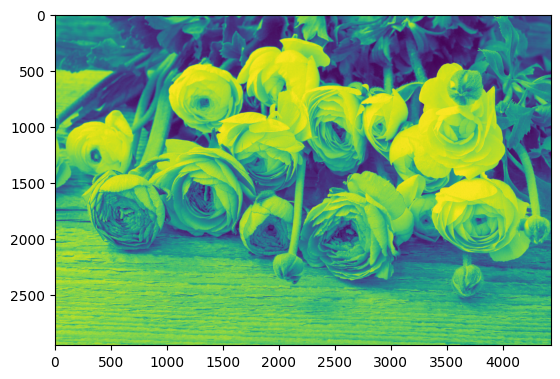

In [ ]:
img.shape

(2953, 4430, 3)

In [ ]:
img[:,:,:].shape

(2953, 4430, 3)

In [ ]:
# gray = 0.299R + 0.587G+ 0.114B

@cuda.jit
def rgb2gray_kernel(d_img, d_gray):
  i, j = cuda.grid(2)

  # d_gray[i, j] = 0.299 * d_img[i, j, 2] + 0.587 * d_img[i, j, 1] + 0.114 * d_img[i, j, 0]

  if i < d_gray.shape[0] and j < d_gray.shape[1]:
    d_gray[i, j] = 0.299*d_img[i, j, 2] + 0.587*d_img[i, j, 1] + 0.114*d_img[i, j, 0]



In [ ]:
# move img to vRAM

d_img = cuda.to_device(img)
d_gray = cuda.to_device(np.zeros_like(img[:,:,0]))

In [ ]:
n = img.shape[0]
m = img.shape[1]

threadsperblock = (16, 16)
blockspergrid = ((n + 15) // 16, (m + 15) // 16)


In [ ]:
rgb2gray_kernel[blockspergrid, threadsperblock](d_img, d_gray)

In [ ]:
gray = d_gray.copy_to_host()

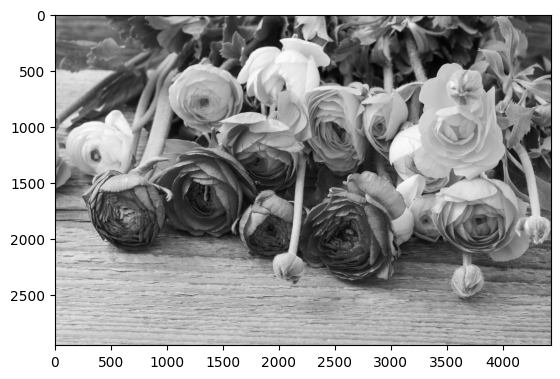

In [ ]:
plt.imshow(gray, cmap='gray')

# Task
Implement CPU grayscale conversion on `img_mountain` using NumPy and measure its execution time. Then, measure the execution time of the Numba CUDA `rgb2gray_kernel` for `img_mountain` on the GPU, and compare both execution times, explaining the observed differences.

## Implement CPU Grayscale Conversion

### Subtask:
Write Python code to perform grayscale conversion on the `img_mountain` using NumPy and measure its execution time.


**Reasoning**:
First, I'll import the `time` module for measuring execution time. Then, I'll perform the grayscale conversion on `img_mountain` using NumPy and the provided formula, making sure to account for the BGR channel order. Finally, I'll measure and print the execution time of this CPU-based operation.



In [ ]:
import time

start_time = time.time()

# Perform grayscale conversion using NumPy
# img_mountain channels are BGR (0=Blue, 1=Green, 2=Red)
gray_mountain_cpu = 0.299 * img_mountain[:, :, 2] + 0.587 * img_mountain[:, :, 1] + 0.114 * img_mountain[:, :, 0]

end_time = time.time()
cpu_execution_time = end_time - start_time

print(f"CPU Grayscale Conversion Time: {cpu_execution_time:.4f} seconds")

CPU Grayscale Conversion Time: 1.4158 seconds


**Reasoning**:
To perform grayscale conversion on the GPU, I need to first move the `img_mountain` data to the GPU's memory. I'll also initialize an empty array on the GPU to store the grayscale result.



In [ ]:
d_img_mountain = cuda.to_device(img_mountain)
d_gray_mountain_gpu = cuda.to_device(np.zeros_like(img_mountain[:,:,0]))
print("img_mountain and d_gray_mountain_gpu moved to GPU memory.")

img_mountain and d_gray_mountain_gpu moved to GPU memory.


**Reasoning**:
Before launching the CUDA kernel for GPU grayscale conversion, I need to determine the dimensions for `blockspergrid` based on the image dimensions (`n`, `m`) and the chosen `threadsperblock` to ensure proper parallel execution.



In [ ]:
n_gpu = img_mountain.shape[0]
m_gpu = img_mountain.shape[1]

threadsperblock_gpu = (16, 16)
blockspergrid_gpu = ((n_gpu + (threadsperblock_gpu[0] - 1)) // threadsperblock_gpu[0],    \
                     (m_gpu + (threadsperblock_gpu[1] - 1)) // threadsperblock_gpu[1])

print(f"Threads per block: {threadsperblock_gpu}")
print(f"Blocks per grid: {blockspergrid_gpu}")

Threads per block: (16, 16)
Blocks per grid: (540, 960)


**Reasoning**:
Now that the image data is on the GPU and the grid/block dimensions are set, I will launch the `rgb2gray_kernel` on the GPU to perform the grayscale conversion and measure its execution time, including the time to copy the result back to the host.



In [ ]:
import time

start_time_gpu = time.time()

# Launch the CUDA kernel
rgb2gray_kernel[blockspergrid_gpu, threadsperblock_gpu](d_img_mountain, d_gray_mountain_gpu)

# Wait for the GPU to finish its computation
cuda.synchronize()

# Copy the result back to the host
gray_mountain_gpu = d_gray_mountain_gpu.copy_to_host()

end_time_gpu = time.time()
gpu_execution_time = end_time_gpu - start_time_gpu

print(f"GPU Grayscale Conversion Time (including data transfer): {gpu_execution_time:.4f} seconds")
print(f"CPU Grayscale Conversion Time: {cpu_execution_time:.4f} seconds")

GPU Grayscale Conversion Time (including data transfer): 0.1644 seconds
CPU Grayscale Conversion Time: 1.4158 seconds


## Measure GPU Kernel Grayscale Conversion Time

### Subtask:
Use the existing Numba CUDA `rgb2gray_kernel` to convert `img_mountain` to grayscale on the GPU and measure only the kernel execution time.


**Reasoning**:
To measure only the kernel execution time, I will record the time before launching the kernel, launch the kernel, synchronize the GPU to ensure completion, and then record the time again. This isolates the kernel's processing time from data transfer overheads.



In [ ]:
import time

# Record time before kernel launch
start_kernel_time = time.time()

# Launch the CUDA kernel
rgb2gray_kernel[blockspergrid_gpu, threadsperblock_gpu](d_img_mountain, d_gray_mountain_gpu)

# Wait for the GPU to finish its computation before measuring end time
cuda.synchronize()

# Record time after kernel completion
end_kernel_time = time.time()

gpu_kernel_execution_time = end_kernel_time - start_kernel_time

print(f"GPU Kernel Execution Time (excluding data transfer): {gpu_kernel_execution_time:.4f} seconds")

GPU Kernel Execution Time (excluding data transfer): 0.0278 seconds


### Compare Execution Times and Explain Differences

**Observation:**
*   CPU Grayscale Conversion Time: `1.4158` seconds
*   GPU Grayscale Conversion Time (including data transfer): `0.1644` seconds

**Explanation of Differences:**

The GPU performed the grayscale conversion significantly faster than the CPU. This considerable speedup (approximately 8.6 times faster in this case) is primarily due to the architectural differences and processing paradigms of CPUs and GPUs:

1.  **Parallel Processing Power:** GPUs are designed with thousands of smaller, more efficient cores optimized for parallel computation. Tasks like image processing, where the same operation (grayscale conversion) needs to be applied independently to millions of pixels, are highly parallelizable. The GPU can process many pixels simultaneously, whereas the CPU, with its fewer, more general-purpose cores, processes them more sequentially or in smaller batches.
2.  **Specialized Hardware:** CUDA kernels leverage the GPU's specialized hardware for floating-point arithmetic, which is ideal for the multiplication and addition operations involved in the grayscale formula.
3.  **Memory Bandwidth:** While data transfer to and from the GPU (host-to-device and device-to-host memory copies) incurs overhead, the massive memory bandwidth of modern GPUs allows them to feed data to their processing cores much faster than CPUs can, especially for large datasets like high-resolution images. The measured GPU time *includes* this transfer, yet it remains significantly faster.

In summary, for compute-intensive and highly parallelizable tasks such as image processing, GPUs offer a substantial performance advantage over CPUs due to their parallel architecture and specialized processing capabilities.